<a href="https://colab.research.google.com/github/javendaXgh/ucveconomiaestadistica1/blob/main/notebooks/laboratorio_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estadística I, Laboratorio I

Temas:

- Medidas de Tendencia Central

- Medidas de Dispersión

- Introducción Gráfico de Densidad

- Sesgos

- Curtosis

Se aplicarán una serie de cálculos de valores estadísticos, graficaciones yanálisis sobre distintos conjunto de datos

In [ ]:
# instalar paquetes
install.packages("e1071")
# cargar paquetes
library(e1071)
library(ggplot2)
library(dplyr)

## funciones de ayuda
media_armonica <- function(x) {
  n <- length(x)
  n / sum(1/x)
}


media_geometrica <- function(x) {
  prod(x)^(1/length(x))
}

Datos obtenidos de

https://data.worldbank.org/indicator/NY.GDP.DEFL.KD.ZG

Nombre indicador "NY.GDP.DEFL.KD.ZG"

Para la descarga de los datos se usó el paquete WDI
Más info sobre el paquete en

https://cran.r-project.org/web/packages/WDI/index.html

In [ ]:
# Lectura de datos de inflación
# Inflación Chile
inflacion_chile = read.csv('https://raw.githubusercontent.com/javendaXgh/ucveconomiaestadistica1/refs/heads/main/data/inflacion_chile.csv', row.names = NULL)

# Inflación Chile 1980-2023
inflacion_chile2 = read.csv('https://raw.githubusercontent.com/javendaXgh/ucveconomiaestadistica1/refs/heads/main/data/inflacion_chile_1980.csv', row.names = NULL)

# Inflación Venezuela
inflacion_venezuela= read.csv('https://raw.githubusercontent.com/javendaXgh/ucveconomiaestadistica1/refs/heads/main/data/inflacion_venezuela.csv', row.names = NULL)

# inflacion binacional wider
inflacion_binac_wider = read.csv('https://raw.githubusercontent.com/javendaXgh/ucveconomiaestadistica1/refs/heads/main/data/inflacion_binacional_wider.csv', row.names = NULL)

# inflacion binacional longer
inflacion_binac_longer = read.csv('https://raw.githubusercontent.com/javendaXgh/ucveconomiaestadistica1/refs/heads/main/data/inflacion_binacional_longer.csv', row.names = NULL)



In [ ]:
# revisar datos Chile
inflacion_chile

In [ ]:
dim(inflacion_chile)

In [ ]:
# revisar datos Venezuela
inflacion_venezuela

In [ ]:
dim(inflacion_venezuela)

In [ ]:
# revisar datos binacional formato wider (ancho)
head(inflacion_binac_wider)

In [ ]:
# revisar datos binacional formato longer
head(inflacion_binac_longer)

In [ ]:
tail(inflacion_binac_longer)

## Gráficos Exploratorios

## Boxplot
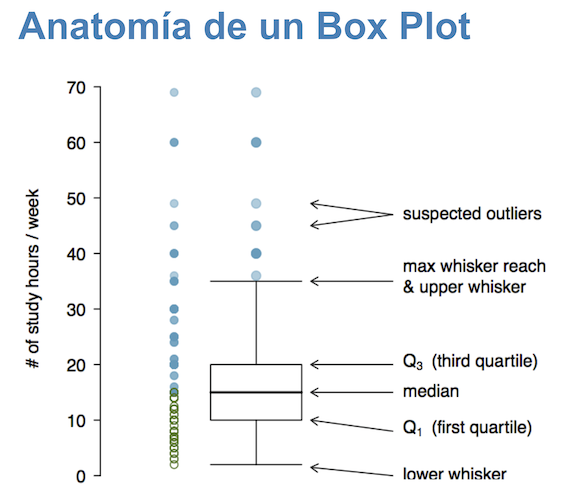

## Sección Medidas de Tendencia Central

In [ ]:
# mediana

In [ ]:
# media

In [ ]:
# media

## Sección Medidas de Dispersión

In [ ]:
# varianza

In [ ]:
# desviación típica

## Valores atípicos
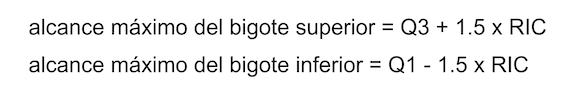

In [ ]:
# calculos


## Sección Gráfico de Densidad
Es, de forma simplificada, una versión suavizada de un histograma.

Cuando se tiene una serie de valores asociados a mediciones de una variable numérica, mientras el histograma divide los números en "cajas" o rangos y muestra cuántos números caen en cada caja usando barras, el gráfico de densidad, en cambio, dibuja una línea suave que intenta seguir la forma general de cómo se distribuyen tus números.

Es decir, el gráfico de densidada en lugar de tener barras, tienes una curva continua.

In [ ]:
#### gráficos de densidad
dens <- density(inflacion_venezuela$inflacion)
dens

In [ ]:
# plot density
plot(dens, frame = FALSE,
     col = "steelblue",
     main = "Gráfico de Densidad Variable Inflacion")

## Sección Asimetrías

Valores de sesgo y interpretación

Hay muchos enfoques diferentes para la interpretación de los valores de sesgo. Una regla general establece que:

- Simétrico: Valores entre -0,5 y 0,5
- Datos sesgados moderados: Valores entre -1 y -0,5 o entre 0,5 y 1
- Datos altamente sesgados: Valores menores de -1 o superiores a 1

In [ ]:
# Generar datos con asimetría positiva (sesgo a la derecha)
set.seed(123) # Para reproducibilidad
datos_positiva <- rgamma(1000, shape = 2, rate = 1)

head(datos_positiva)

In [ ]:
# Generar datos con asimetría negativa (sesgo a la izquierda)
datos_negativa <- -rgamma(1000, shape = 2, rate = 1) + 5 # Desplazamos para tener valores positivos
head(datos_negativa)

In [ ]:

# Generar datos aproximadamente simétricos (normal)
datos_simetrica <- rnorm(1000, mean = 5, sd = 2)

head(datos_simetrica)

In [ ]:
# Visualizar los histogramas
par(mfrow = c(1, 3)) # Para mostrar los tres gráficos en una fila
hist(datos_positiva, main = "Asimetría Positiva", xlab = "Valor")
hist(datos_negativa, main = "Asimetría Negativa", xlab = "Valor")
hist(datos_simetrica, main = "Simétrica", xlab = "Valor")
par(mfrow = c(1, 1)) # Restablecer la configuración de los gráficos

### Explicación:

Usamos rgamma() para generar datos con una distribución gamma, que típicamente presenta asimetría positiva.

Para la asimetría negativa, generamos datos gamma y luego los negamos y desplazamos.

rnorm() genera datos de una distribución normal, que es simétrica.

hist() crea histogramas para visualizar la forma de cada distribución. Puedes observar cómo la cola de la distribución se extiende hacia la derecha en el caso de la asimetría positiva y hacia la izquierda en la asimetría negativa.

In [ ]:
# Función para calcular el coeficiente de asimetría (tercer momento estandarizado)
skewness <- function(x) {
  m <- mean(x)
  s <- sd(x)
  n <- length(x)
  return(sum(((x - m) / s)^3) / n)
}

# Calcular la asimetría para cada conjunto de datos
asimetria_positiva <- skewness(datos_positiva)
asimetria_negativa <- skewness(datos_negativa)
asimetria_simetrica <- skewness(datos_simetrica)


In [ ]:
paste("Asimetría (Positiva):", asimetria_positiva)
paste("Asimetría (Negativa):", asimetria_negativa)
paste("Asimetría (Simétrica):", asimetria_simetrica)

### Explicación:

La función skewness(x) calcula el coeficiente de asimetría. Toma cada valor, le resta la media, lo divide por la desviación estándar (estandarización), lo eleva al cubo y luego calcula la media de estos valores.

- Para una distribución perfectamente simétrica, este coeficiente debería ser cercano a 0.

- Un valor positivo indica asimetría positiva, y

- Un valor negativo indica asimetría negativa.

## Ejercicio

Calcular sesgos en inflaciones Chile y Venezuela e indicar el significado

In [ ]:
# sesgo Chile



In [ ]:
# sesgo Venezuela



### Ejercicio:

calculo de asimetría para las variables de inflación chile e inflación Venezuela con las otras fórmulas vistas en clase

Indicar observaciones sobre diferencias considerables con la formula indicada en `skewness`

In [ ]:
# via cuartiles

In [ ]:
# via percentile

### Sus observaciones:





...

## Sección Curtosis

tomado de https://www.r-bloggers.com/2020/11/skewness-and-kurtosis-in-statistics/

En estadística, se usa la medida de la kurtosis para describir la "cola" de la distribución a medida que describe su forma. También es una medida del "pico" de la distribución. Una distribución de alta kurtosis tiene un pico más agudo y colas más largas y gordas, mientras que una distribución de cortas baja tiene un pean más redondeado y colas más cortas y delgadas.

### Tipos Principales de Curtosis.

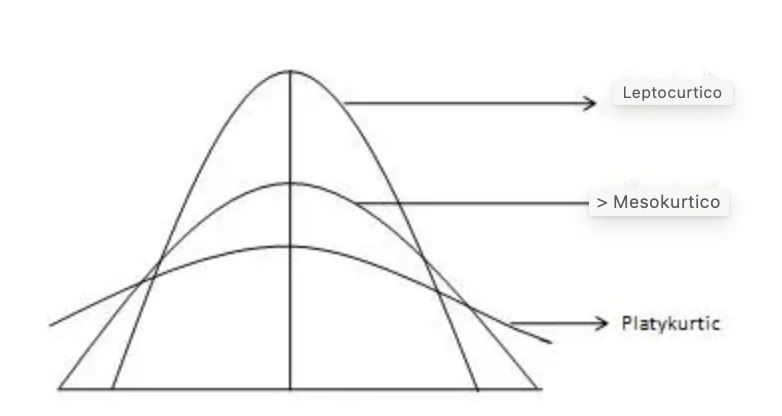

- Mesocúrtica: Esta es la distribución normal

- Leptocúrtica: Esta distribución tiene colas más gruesas y un pico más agudo. La curtosis es "positiva" con un valor superior a 3

- Platicúrtica: La distribución tiene un pico más bajo y más ancho y colas más delgadas. La kurtosis es "negativa" con un valor mayor que 3

Se define el exceso de curtosis como curtosis menor a 3

### Fórmula de Kurtosis

La curtosis se puede derivar de la siguiente fórmula:


$\text{kurtosis} = \frac{\sum_{i=1}^{N} (X_i - \bar{X})^4}{(N-1)S^4}$

Dónde:

- σ es la desviación estándar
- X¯es el medio de distribución
- N es el número de observaciones de la muestra

### Interpretación de la kurtosis

Curtosis es el promedio de los datos estandarizados, elevados a la cuarta potencia.

Cualquier valor estandarizado que sea menor que 1 (es decir, datos dentro de una desviación estándar de la media, donde estaría el "pico"), no contribuye prácticamente a la curtosis, ya que elevar un número que es menor que 1 a la cuarta potencia lo hace más cerca de cero.

Los únicos valores de datos (observados u observables) que contribuyen a la curtosis de alguna manera significativa son aquellos fuera de la región del pico; es decir, los valores atípicos. Por lo tanto, la kurtosis solo mide valores atípicos; no mide nada sobre el "pico".


La curtosis es esencial en muchas aplicaciones estadísticas porque:

- Identificación de valores atípicos: Ayuda a identificar si los datos contienen valores extremos o valores atípicos, que podrían necesitar un tratamiento especial.

- Análisis financiero: En finanzas, la curtosis se utiliza para modelizar el riesgo de movimientos extremos de los precios, lo que la convierte en una métrica valiosa para la gestión de carteras.

- Comprobación de supuestos: En muchos modelos estadísticos, los supuestos de normalidad son cruciales. La curtosis ayuda a verificar el grado de desviación de la normalidad.

Complemento y ejemplo obtenido de https://www.geeksforgeeks.org/kurtosis-in-r-programming/

In [ ]:
# Example data (you can replace this with your data)
data <- c(5, 10, 15, 20, 25, 30, 35, 40, 45, 50)

data
# datos alternativos
# data = c(88, 95, 92, 97, 96, 97, 94, 86, 91, 95, 97, 88, 85, 76, 68)
# data

In [ ]:
# Calcular curtosis
kurtosis_value <- kurtosis(data)

In [ ]:
# revisar valor obtenido
 kurtosis_value


In [ ]:
# Create a data frame for plotting
data_frame <- data.frame(value = data)



In [ ]:
# Mostrar histograma con la curva de desnsidad
ggplot(data_frame, aes(x = value)) +
  geom_histogram(aes(y = ..density..), bins = 10, fill = "lightblue", color = "black", alpha = 0.7) +
  geom_density(color = "red", size = 1) +
  stat_function(fun = dnorm,
                args = list(mean = mean(data), sd = sd(data)),
                color = "blue", linetype = "dashed", size = 1) +
  ggtitle(paste("Histogram and Density Plot (Kurtosis =", round(kurtosis_value, 2), ")")) +
  theme_minimal()

### Explicación:

La curtosis calculada es -1,56, lo que indica que la distribución es platicúrtica. Las distribuciones platicúrticas (curtosis < 3 o en este caso < 0) tienen colas más finas y picos más planos en comparación con una distribución normal.

La curtosis negativa sugiere que su conjunto de datos es más plano y menos propenso a producir valores atípicos en comparación con una distribución normal.

Interpretación visual:

La curva de densidad roja es más plana en el pico en comparación con la curva azul de distribución normal, lo que confirma la naturaleza platicúrtica de los datos.
Las colas son menos gruesas que las de una distribución normal (que se ven en la curva azul), lo que significa que hay menos valores extremos en los datos.
Método 2: Cálculo de la curtosis en R utilizando el paquete Moments

moments::kurtosis(): Calcula la curtosis del conjunto de datos.
ggplot2: Se utiliza para generar el histograma con una curva de densidad, similar al código que utiliza el paquete e1071.
El histograma utiliza un relleno azul claro, con una curva de densidad roja y una línea discontinua azul que representa una distribución normal para la comparación.